Examine the distribution and relationships within the data using various visualization techniques.

## Import dependancies

In [30]:
import import_ipynb
data = __import__("01_data_exploration")
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Correlation Heatmap and Pair Plot

In [31]:
numeric_df = data.df.select_dtypes(include=[np.number])
print(f'Number of numerical columns: {numeric_df.shape[1]}')

Number of numerical columns: 17


<function matplotlib.pyplot.show(close=None, block=None)>

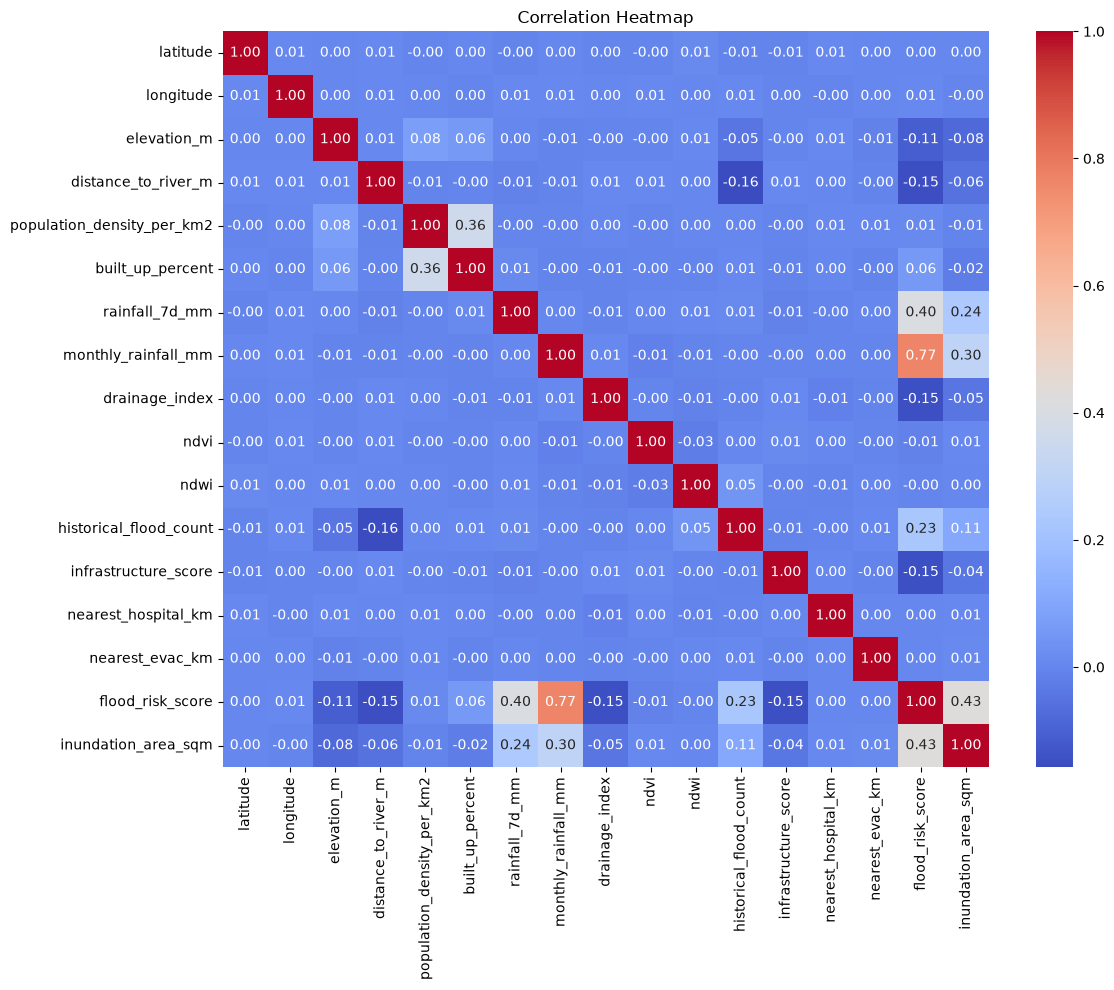

In [32]:
plt.figure(figsize=(12,10))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show

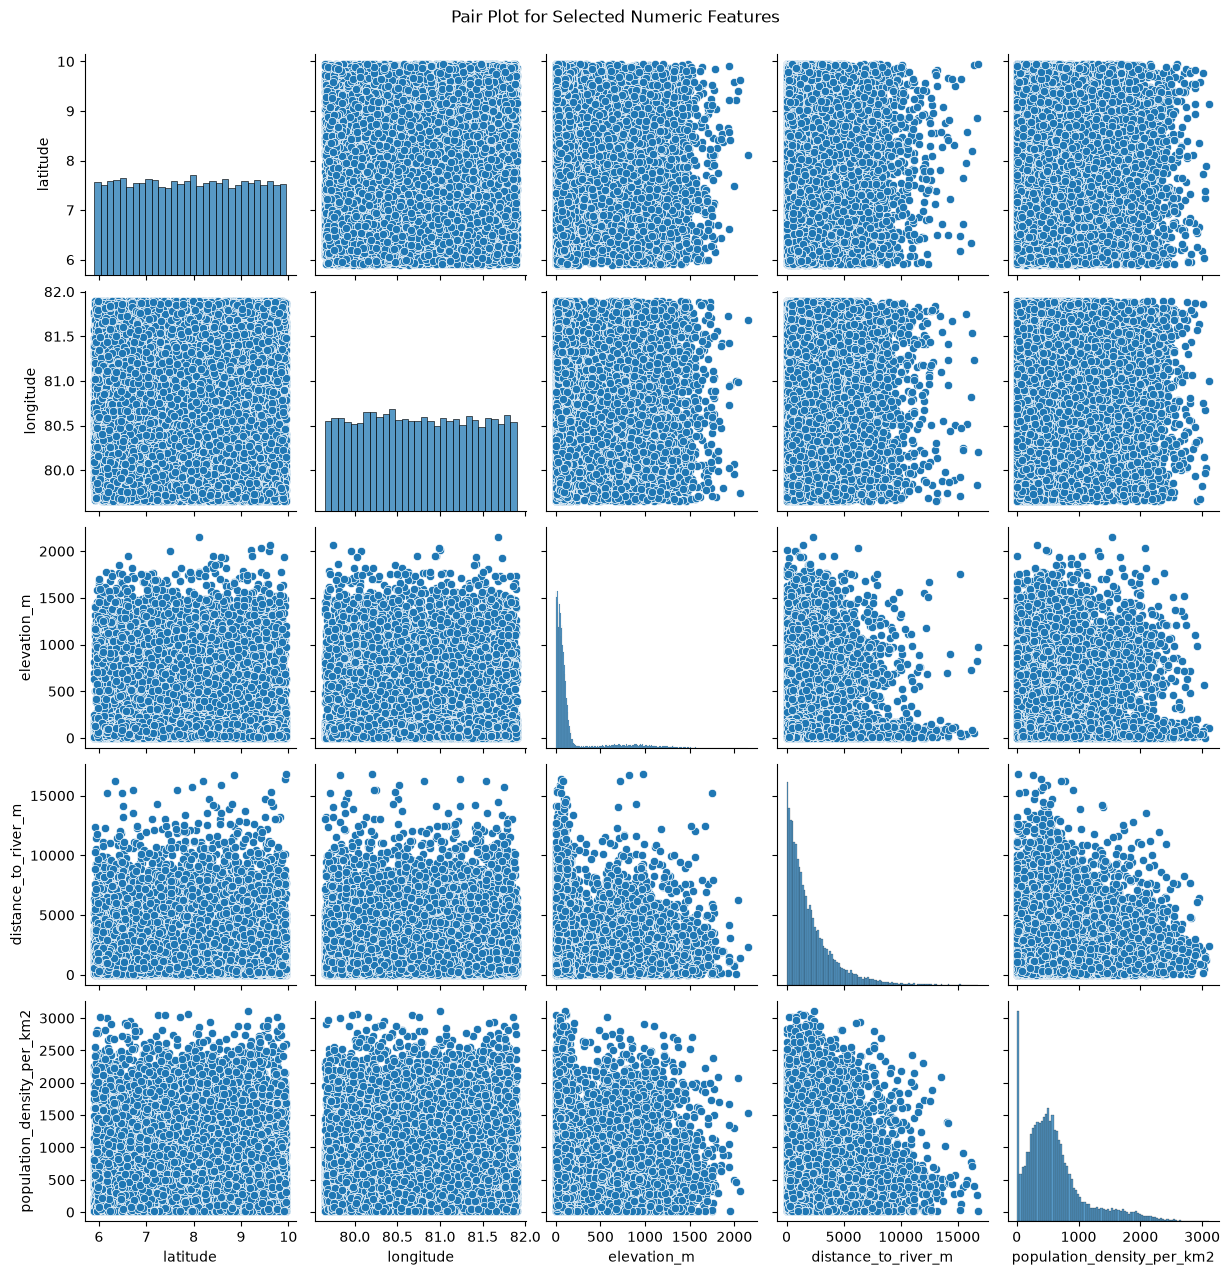

In [33]:
cols_to_plot = numeric_df.columns.tolist()[:5]
sns.pairplot(numeric_df[cols_to_plot])
plt.suptitle('Pair Plot for Selected Numeric Features', y=1.02)
plt.show()

## Visualizing the distribution of flood orrurance

C:\Users\USER\AppData\Local\Temp\ipykernel_8052\3154155646.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data.df, x='flood_occurrence_current_event', palette='viridis')


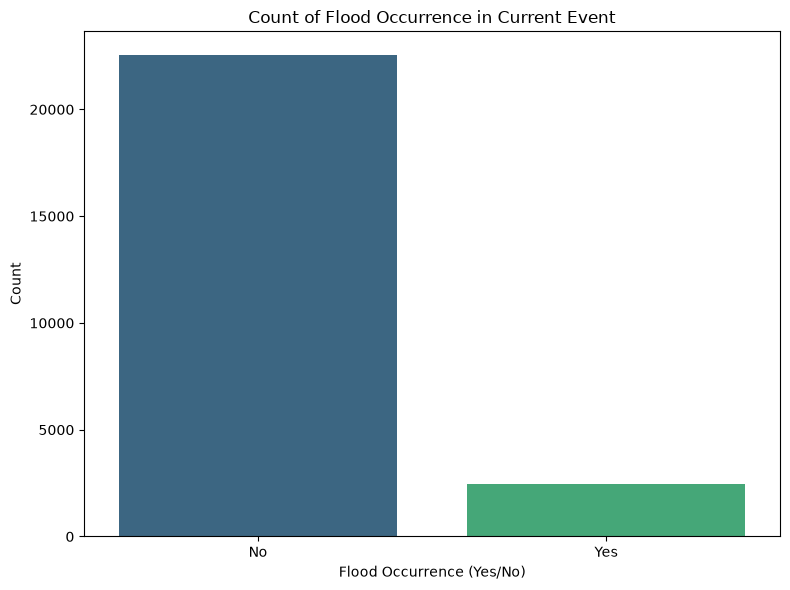

In [34]:
plt.figure(figsize=(8,6))
sns.countplot(data=data.df, x='flood_occurrence_current_event', palette='viridis')
plt.title('Count of Flood Occurrence in Current Event')
plt.xlabel('Flood Occurrence (Yes/No)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Is good to live

C:\Users\USER\AppData\Local\Temp\ipykernel_8052\4146998261.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


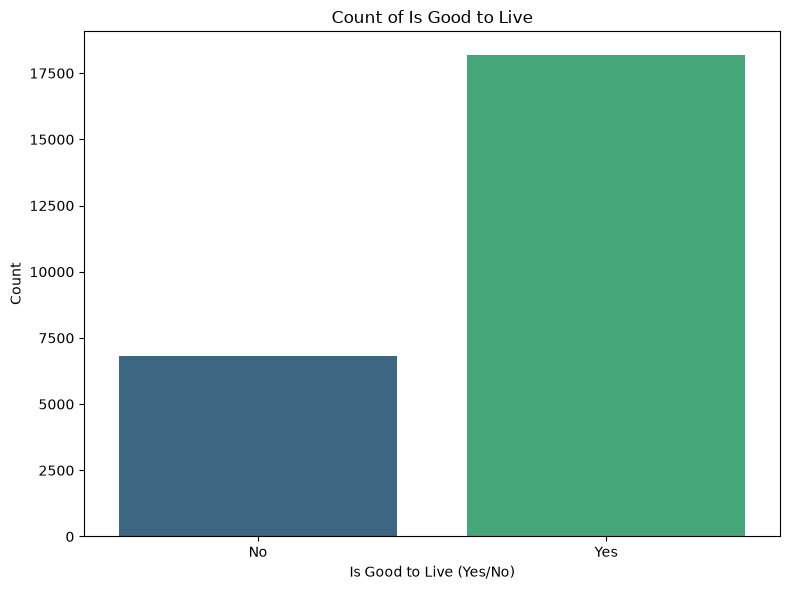

In [35]:
plt.figure(figsize=(8, 6))

sns.countplot(
    data=data.df,
    x='is_good_to_live',
    palette='viridis'
)

plt.title('Count of Is Good to Live')

plt.xlabel('Is Good to Live (Yes/No)')

plt.ylabel('Count')

plt.tight_layout()

plt.show()

## Visualizing value count of each district

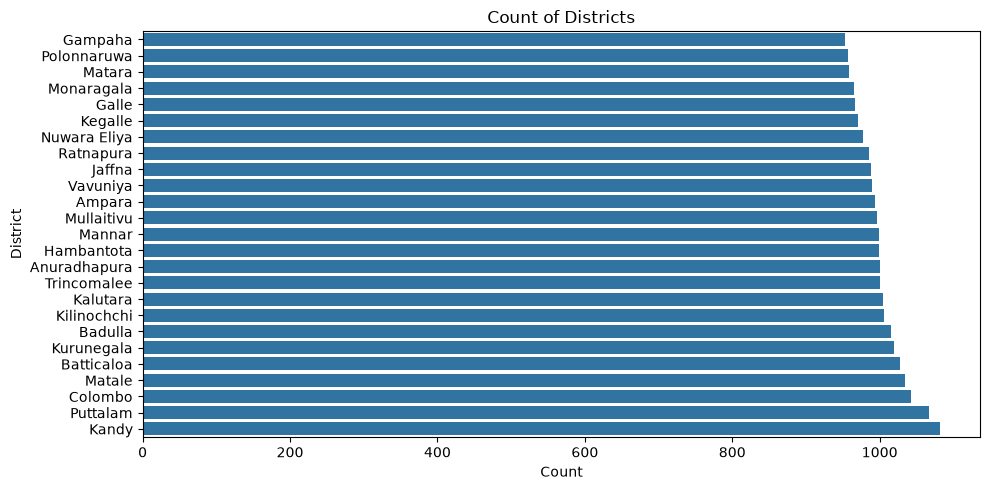

In [36]:
plt.figure(figsize=(10, 5))
district_order = data.df['district'].value_counts().sort_values().index

sns.countplot(
    data=data.df,
    y='district',
    order=district_order,
    legend=False
)
plt.title('Count of Districts')
plt.xlabel('Count')
plt.ylabel('District')
plt.tight_layout()
plt.show()

## Where is the risk concentrated?

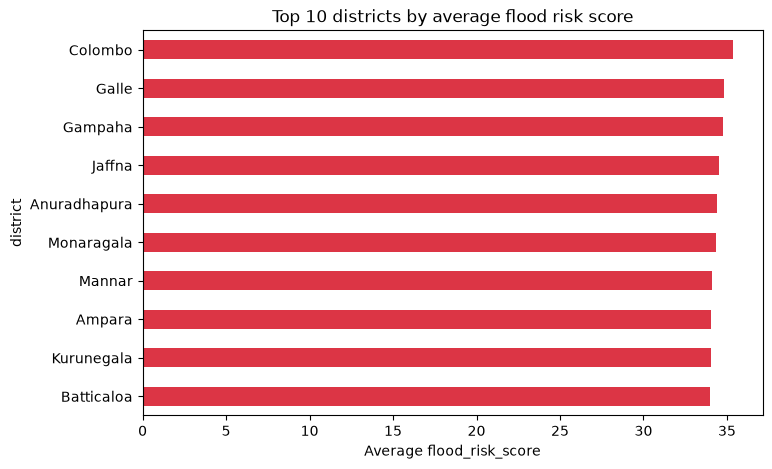

In [37]:
district_risk = (
    data.df.groupby("district")["flood_risk_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(8, 5))
district_risk.plot(kind="barh", ax=ax, color="#dc3545")
ax.invert_yaxis()
ax.set_title("Top 10 districts by average flood risk score")
ax.set_xlabel("Average flood_risk_score")
plt.show()

## Count of flood events, not good to live and reason of not good to live

In [42]:
data.df.columns = data.df.columns.str.strip()

active_floods = (
    data.df["flood_occurrence_current_event"]
    .astype(str)
    .str.strip()
    .str.lower()
    == "yes"
).sum()
print(f"Rows flagged as an active flood event: {active_floods}")

not_good_to_live = (
    data.df["is_good_to_live"].astype(str).str.strip().str.lower() == "no"
).sum()
print(f"Locations flagged as NOT good to live: {not_good_to_live}")

reasons = data.df.loc[
    data.df["is_good_to_live"].astype(str).str.strip().str.lower() == "no",
    "reason_not_good_to_live",
].value_counts(dropna=False)

print("\nReasons breakdown:")
print(reasons)

Rows flagged as an active flood event: 2472
Locations flagged as NOT good to live: 6828

Reasons breakdown:
reason_not_good_to_live
Poor infrastructure                                                             4516
No road access                                                                   844
High flood risk                                                                  735
Poor infrastructure; No road access                                              344
High flood risk; Poor infrastructure                                             311
High flood risk; No road access                                                   41
High flood risk; Poor infrastructure; No road access                              19
Poor infrastructure; Overcrowded/Urban risk                                       11
No road access; Overcrowded/Urban risk                                             2
High flood risk; Overcrowded/Urban risk                                            2
High flood risk; P